<a href="https://colab.research.google.com/github/ianelgar40/IansMIS433/blob/main/OPS466_python_exersize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **What role does Gemini Ai play in the tutorial? Identify key steps shown in the video.**

He is essentially asking the ai to do a task and it is generating the code for him.

Another way Genini could be used is as a predictor of code to come. Oftentimes when I write code, the Ai thinks it knows what I want and gives me a suggession. Sometimes the suggession is what I want, other times it is not.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [31]:
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [32]:
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [33]:
df.describe(include = 'all')

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [34]:
df.loc[(df['population'] < 20) & (df['housing_median_age'] > 35)]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
1466,-117.19,32.75,52.0,25.0,5.0,13.0,5.0,0.5360,162500.0
4502,-118.04,33.90,36.0,15.0,5.0,15.0,6.0,0.4999,162500.0
5027,-118.12,34.71,46.0,40.0,10.0,14.0,7.0,1.1250,225000.0
14501,-122.14,37.50,46.0,30.0,4.0,13.0,5.0,15.0001,500001.0
15369,-122.29,37.81,46.0,12.0,4.0,18.0,7.0,0.4999,67500.0
16309,-122.50,37.79,52.0,8.0,1.0,13.0,1.0,15.0001,500001.0
16801,-123.17,40.31,36.0,98.0,28.0,18.0,8.0,0.5360,14999.0


In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Assuming 'df' is already loaded from previous cells
# Define features (X) and target (y)
X = df.drop('median_house_value', axis=1) # Features are all columns except the target
y = df['median_house_value'] # Target is 'median_house_value'

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Regressor model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared (R^2): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R-squared (R^2): 0.6485
Root Mean Squared Error (RMSE): 69597.06


,feature,importance
7,median_income,0.509807
0,longitude,0.178567
1,latitude,0.154659
2,housing_median_age,0.060123
5,population,0.032278
4,total_bedrooms,0.026377
3,total_rooms,0.021194
6,households,0.016995


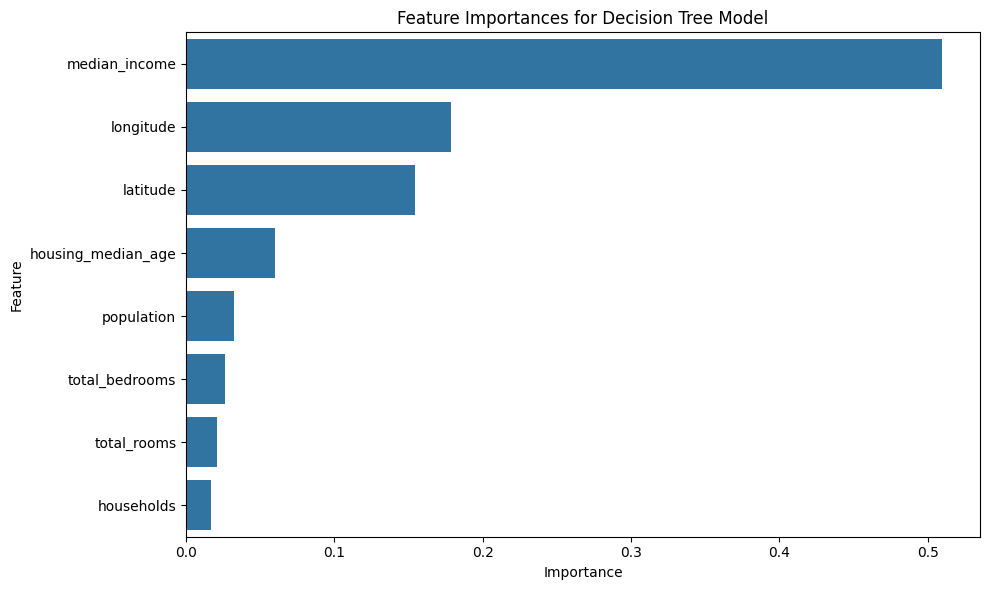

In [43]:
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
display(feature_importances)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title('Feature Importances for Decision Tree Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [44]:
# Get the top 5 feature names
top_5_features = feature_importances['feature'].head(5).tolist()

# Filter the original feature set (X) to include only the top 5 predictors
X_top5 = X[top_5_features]

# Split data into training and testing sets for the new model
X_train_top5, X_test_top5, y_train_top5, y_test_top5 = train_test_split(X_top5, y, test_size=0.2, random_state=42)

# Initialize and train a new Decision Tree Regressor model with top 5 features
model_top5 = DecisionTreeRegressor(random_state=42)
model_top5.fit(X_train_top5, y_train_top5)

# Make predictions on the test set using the new model
y_pred_top5 = model_top5.predict(X_test_top5)

# Evaluate the new model
r2_top5 = r2_score(y_test_top5, y_pred_top5)
rmse_top5 = np.sqrt(mean_squared_error(y_test_top5, y_pred_top5))

print(f"Model with Top 5 Predictors:")
print(f"R-squared (R^2): {r2_top5:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_top5:.2f}")

Model with Top 5 Predictors:
R-squared (R^2): 0.6777
Root Mean Squared Error (RMSE): 66639.45


# **What part of the workflow did you find most challenging?**

I found that in order to predict stuff you still need to have a fundemntal understanding of statistical modeling and machine learning.

My first prediction got a worse RMSE and R^2 because the model was likily overfitted because it was using too many predictors that had bias towards one another.

In other words, the input that you put into ai will directly determine the output that ai gives you.

I am sure that I can get a better prediction model with more prompts.



# **How do you think you can use Colab and other AI tools in future data work?**

Prediction analysis and data cleaning. Also making charts and visual tools.

I also recently got introduced to AI Google Studio. It is a very cool tool, I made a game with graphics as a MVP within 5 minutes and four prompts.

This is a big deal because in IT projects, making a MVP cost a lot of money and is used for testing to see if users would even like to use the product. Being able to look at your IT vision can save millions of dollars and time so they can focus on additional features that ai may be unable to add.